# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [1]:
import pandas as pd
import sklearn

### Step 1. Load the data


In [2]:
df = pd.read_csv("../../../datasets/bmi_and_life_expectancy.csv")
df.head()

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = df[["BMI"]]
y = df["Life expectancy"]

### Step 2.b print the type of each

In [4]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
from pandas.api.types import is_numeric_dtype

if is_numeric_dtype(y):
    target_type = "Numerical"
    ml_task = "Regression"
else:
    target_type = "Categorical"
    ml_task = "Classification"

print(f"Target type: {target_type}")
print(f"Machine Learning Task: {ml_task}")

Target type: Numerical
Machine Learning Task: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [7]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (163, 1)
y shape: (163,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [9]:
print("X summary:")
print(X.agg(['min', 'max', 'median', 'mean', 'std']))

print("\ny summary:")
print(y.agg(['min', 'max', 'median', 'mean', 'std']))

X summary:
              BMI
min     19.866920
max     30.995630
median  25.320540
mean    24.792378
std      2.427900

y summary:
min       44.500000
max       84.600000
median    71.800000
mean      69.666933
std        8.981933
Name: Life expectancy, dtype: float64


### Step 5. Plot the feature vs the target

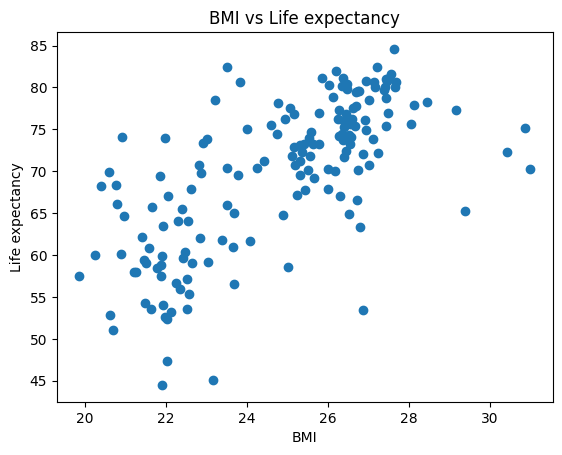

In [10]:
import matplotlib.pyplot as plt

plt.scatter(X["BMI"], y)
plt.xlabel("BMI")
plt.ylabel("Life expectancy")
plt.title("BMI vs Life expectancy")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [11]:
correlation_value = df["BMI"].corr(df["Life expectancy"])

if correlation_value > 0:
    relationship = "Increasing (Positive Correlation)"
elif correlation_value < 0:
    relationship = "Decreasing (Negative Correlation)"
else:
    relationship = "None (No Correlation)"

print(f"Correlation Coefficient: {correlation_value:.2f}")
print(f"The relationship is: {relationship}")

Correlation Coefficient: 0.68
The relationship is: Increasing (Positive Correlation)


### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

linear_model = LinearRegression()
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

### Step 8. Split the dataset into train and test sets

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 9. Train both models on the training set

In [14]:
linear_model.fit(X_train, y_train)
poly_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


### Step 10. Evaluate and compare which of the two models score better on the `train` set

In [16]:
linear_train_score = linear_model.score(X_train, y_train)
poly_train_score = poly_model.score(X_train, y_train)

print(f"Linear Regression train R^2 score: {linear_train_score:.4f}")
print(f"Polynomial Regression train R^2 score: {poly_train_score:.4f}")

if linear_train_score > poly_train_score:
    print("Linear Regression performs better on the train set.")
elif poly_train_score > linear_train_score:
    print("Polynomial Regression performs better on the train set.")
else:
    print("Both models perform equally on the train set.")

Linear Regression train R^2 score: 0.4940
Polynomial Regression train R^2 score: 0.5144
Polynomial Regression performs better on the train set.


### Step 11. Evaluate and compare which of the two models score better on the `test` set

In [17]:
linear_test_score = linear_model.score(X_test, y_test)
poly_test_score = poly_model.score(X_test, y_test)

print(f"Linear Regression test R^2 score: {linear_test_score:.4f}")
print(f"Polynomial Regression test R^2 score: {poly_test_score:.4f}")

if linear_test_score > poly_test_score:
    print("Linear Regression performs better on the test set.")
elif poly_test_score > linear_test_score:
    print("Polynomial Regression performs better on the test set.")
else:
    print("Both models perform equally on the test set.")

Linear Regression test R^2 score: 0.3540
Polynomial Regression test R^2 score: 0.4031
Polynomial Regression performs better on the test set.
